<a href="https://colab.research.google.com/github/IamMubashir/ML-Project-Files/blob/main/ML%20project%20Phase%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Data Overview
In this section, we load the dataset and identify the number of instances (rows) and features (columns) present, followed by a detailed look at the data types and characteristics of each feature.

In [1]:
import pandas as pd

# Load the dataset
file_path = '/content/Mubashir Hanif_23-SEt046_Premier League Player Stats.csv'
df = pd.read_csv(file_path)

# 1. Number of instances & columns
rows, cols = df.shape
print(f'Number of Instances (Rows): {rows}')
print(f'Number of Columns (Features): {cols}')

# Display the first few rows to understand the structure
display(df.head())

Number of Instances (Rows): 540
Number of Columns (Features): 10


,Rank,PLAYER,TEAM,GP,GS,MIN,G,ASST,SHOTS,SOG
0,1,Jamie Vardy,Leicester City,35,34,3034,23,5,71,43
1,2,Danny Ings,Southampton,38,32,2812,22,2,66,38
2,3,Pierre-Emerick Aubameyang,Arsenal,36,35,3138,22,3,70,42
3,4,Raheem Shaquille Sterling,Manchester City,33,30,2660,20,1,68,38
4,5,Mohamed Salah Ghaly,Liverpool,34,33,2884,19,10,95,59


## 2. Detail about each feature
Below is the summary of each feature, including its data type and the count of non-null values, which helps in identifying missing data for the preprocessing phase.

In [2]:
# 2. Detail about each feature
feature_info = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Null Count': df.isnull().sum(),
    'Unique Values': df.nunique()
})

display(feature_info)

# Statistical summary for numerical features
print('\nStatistical Summary of Numerical Features:')
display(df.describe())

,Data Type,Non-Null Count,Null Count,Unique Values
Rank,int64,540,0,540
PLAYER,object,540,0,540
TEAM,object,540,0,20
GP,int64,540,0,39
GS,int64,540,0,39
MIN,int64,540,0,419
G,int64,540,0,22
ASST,int64,540,0,14
SHOTS,int64,540,0,64
SOG,int64,540,0,44



Statistical Summary of Numerical Features:


,Rank,GP,GS,MIN,G,ASST,SHOTS,SOG
count,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000
mean,270.500000,18.985185,15.090741,1353.657407,1.825926,1.275926,12.331481,5.909259
std,156.028843,12.847896,12.437641,1091.594162,3.551277,2.129346,16.651935,9.253446
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,135.750000,7.000000,2.000000,241.500000,0.000000,0.000000,0.000000,0.000000
50%,270.500000,20.000000,13.500000,1219.500000,0.000000,0.000000,6.000000,2.000000
75%,405.250000,30.000000,26.000000,2295.500000,2.000000,2.000000,17.000000,7.000000
max,540.000000,38.000000,38.000000,3420.000000,23.000000,20.000000,95.000000,59.000000


## 3. Data Preprocessing
In this step, we will:
1. Drop columns that don't contribute to the model (like 'Rank' and 'PLAYER').
2. Encode the 'TEAM' categorical variable.
3. Scale the numerical features to ensure the algorithms perform optimally.

In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Dropping non-predictive columns for the model phase
df_processed = df.drop(['Rank', 'PLAYER'], axis=1)

# Encoding Categorical Variable: TEAM
le = LabelEncoder()
df_processed['TEAM'] = le.fit_transform(df_processed['TEAM'])

# Separating Features and Target (Assuming 'G' or 'Rank' might be targets, but we'll prepare features first)
# Let's assume we want to predict 'G' (Goals) as a baseline for this demonstration
X = df_processed.drop('G', axis=1)
y = df_processed['G']

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Preprocessing complete.')
print(f'Training set size: {X_train.shape[0]}')
print(f'Testing set size: {X_test.shape[0]}')

# Displaying the first few rows of the processed features
pd.DataFrame(X_train_scaled, columns=X.columns).head()

Preprocessing complete.
Training set size: 432
Testing set size: 108


,TEAM,GP,GS,MIN,ASST,SHOTS,SOG
0,-1.284847,-0.507078,-0.368835,-0.367559,-0.557715,-0.344505,-0.395799
1,-0.064182,-0.977833,-1.098992,-1.097494,-0.557715,-0.407781,-0.395799
2,-1.110467,-1.448587,-1.180120,-1.210361,-0.557715,-0.724163,-0.624848
3,1.156484,-0.036324,0.117937,0.113514,-0.557715,-0.534334,-0.510324
4,-1.633609,-0.271701,-0.125449,-0.095568,-0.092594,-0.154676,-0.166750


## 4. Model Application & Evaluation
In this section, we apply the following algorithms:
1. Linear Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree Regressor
4. Random Forest Regressor

We will evaluate them using Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

--- Linear Regression ---
MAE: 0.9879, MSE: 3.2727, RMSE: 1.8091, R2: 0.8471

--- KNN Regressor ---
MAE: 1.0778, MSE: 3.9659, RMSE: 1.9915, R2: 0.8147

--- Decision Tree ---
MAE: 1.4444, MSE: 6.1111, RMSE: 2.4721, R2: 0.7145

--- Random Forest ---
MAE: 0.9703, MSE: 3.1271, RMSE: 1.7684, R2: 0.8539



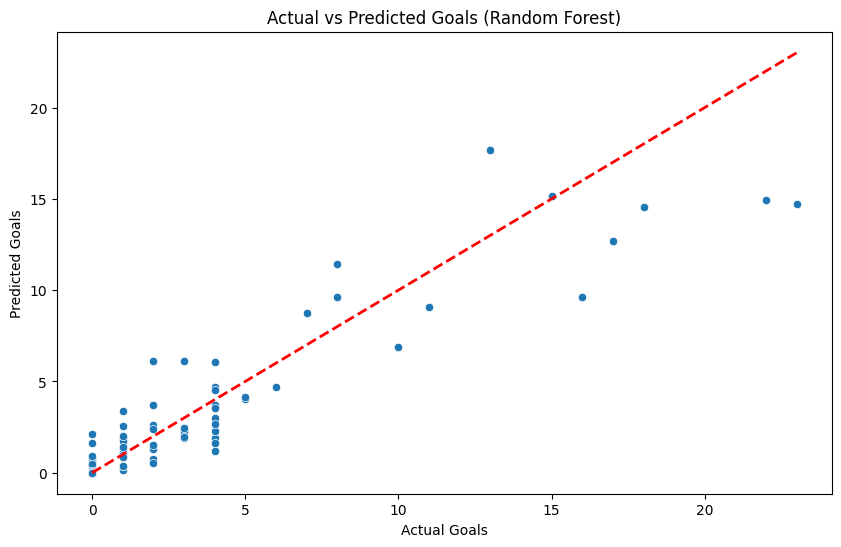

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dictionary to store results
results = {}

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
    print(f"--- {name} ---")
    print(f"MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}\n")

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
evaluate_model("Linear Regression", y_test, y_pred_lr)

# 2. KNN Regressor (k=5)
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
evaluate_model("KNN Regressor", y_test, y_pred_knn)

# 3. Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
evaluate_model("Decision Tree", y_test, y_pred_dt)

# 4. Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
evaluate_model("Random Forest", y_test, y_pred_rf)

# Visualization: Comparing Actual vs Predicted for the best performing model (Random Forest typical)
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Goals')
plt.ylabel('Predicted Goals')
plt.title('Actual vs Predicted Goals (Random Forest)')
plt.show()

## 5. Additional Models and Final Comparison
To ensure a comprehensive analysis, we add Support Vector Machines and Neural Networks, followed by a summary of all model performances.

--- SVM Regressor ---
MAE: 1.2499, MSE: 6.3979, RMSE: 2.5294, R2: 0.7011

--- Neural Network ---
MAE: 1.0581, MSE: 3.2036, RMSE: 1.7899, R2: 0.8503



/tmp/ipykernel_6297/2201611342.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=res_df.index, y=res_df['RMSE'], palette='viridis')


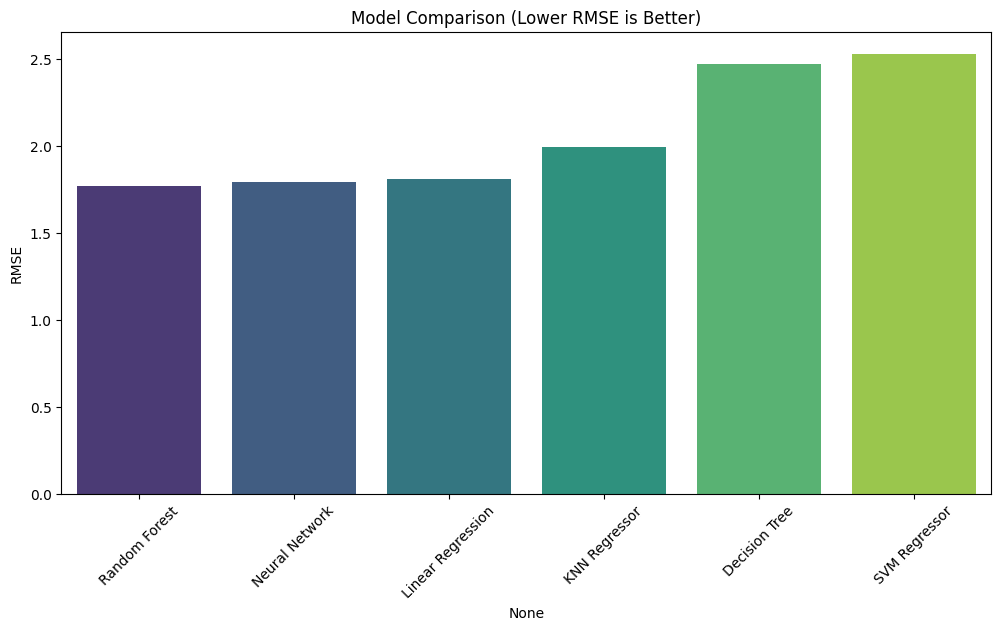

Final Comparison Table:


,MAE,MSE,RMSE,R2
Random Forest,0.970278,3.127144,1.768373,0.853915
Neural Network,1.058108,3.203644,1.789873,0.850341
Linear Regression,0.987947,3.272728,1.809068,0.847114
KNN Regressor,1.077778,3.965926,1.991463,0.814731
Decision Tree,1.444444,6.111111,2.472066,0.714518
SVM Regressor,1.249948,6.397941,2.529415,0.701119


In [5]:
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# 5. Support Vector Regression (SVR)
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)
evaluate_model("SVM Regressor", y_test, y_pred_svr)

# 6. Neural Network (MLP Regressor)
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)
evaluate_model("Neural Network", y_test, y_pred_mlp)

# Final Comparison Visualization
res_df = pd.DataFrame(results).T
res_df = res_df.sort_values(by='RMSE')

plt.figure(figsize=(12, 6))
sns.barplot(x=res_df.index, y=res_df['RMSE'], palette='viridis')
plt.title('Model Comparison (Lower RMSE is Better)')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.show()

print("Final Comparison Table:")
display(res_df)